# Análise de Dados Imobiliários

## 1. Objetivo

Neste projeto, vamos analisar dados imobiliários para identificar padrões e relações entre as características das regiões e o valor dos imóveis.

Ao final, será desenvolvido um modelo simples de Machine Learning para verificar se essas características podem ser utilizadas para estimar o valor dos imóveis.

## 2. Metodologia

O projeto será desenvolvido nas seguintes etapas:

1. Carregamento dos dados
2. Entendimento e exploração dos dados
3. Limpeza e validação
4. Análise exploratória
5. Visualização dos dados
6. Desenvolvimento de um modelo de Machine Learning
7. Avaliação do modelo
8. Interpretação dos resultados

## 3. Conhecendo os Dados

- Quantas linhas e colunas existem?
20640
- Quais são as colunas?

MediumIncome (mediana do salário das pessoas do quarteirão)
HouseAge (Idade de um imóvel)
AverageRooms (Média de quartos por casa)
AverageBedrooms (Média de quartos (cama) por casa)
Population (População por quarteirão)
AverageOccupation (Quantidade média de moradores por casa)
Latitude
Longitude
MediumHouseValue (mediana do valor das casas de um quarteirão)

- Que tipo de dado cada coluna possui?
Todos tipo Float ou inteiro
- Existem valores ausentes?
Não

In [3]:
from sklearn.datasets import fetch_california_housing
dados = fetch_california_housing(as_frame=True)

df = dados.frame
df.head()
# df.info()

# A nossa principal variável é:
# 🎯 MedHouseVal
# Ela representa o valor mediano das casas em determinada região.

# É essa variável que queremos:
# 1. Analisar;
# 2. Entender quais fatores possuem relação com ela;
# 3. Posteriormente tentar prever utilizando Machine Learning.
# As outras colunas serão as características que vamos investigar.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Análise Exploratória
### 4.1 Variável de Interesse

MedHouseVal

### 4.2 Distribuição dos Valores dos Imóveis

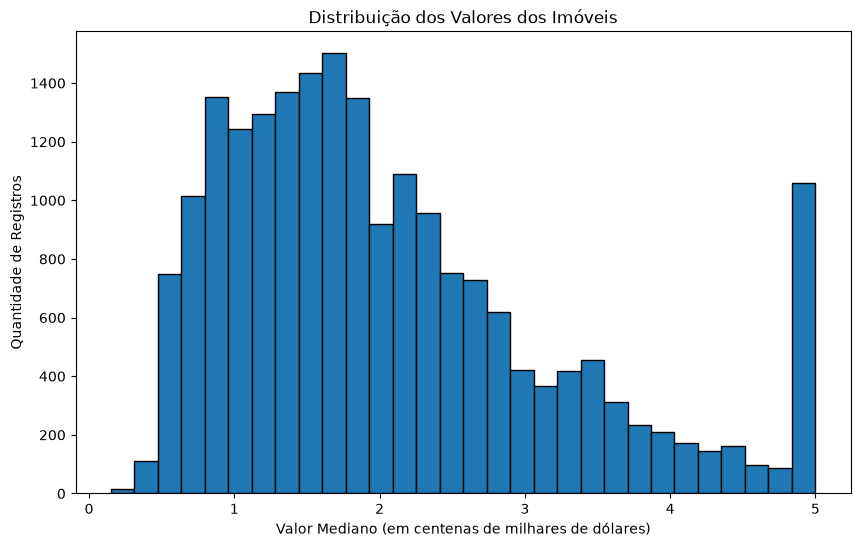

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.hist(df["MedHouseVal"], bins=30, edgecolor="black")

plt.title("Distribuição dos Valores dos Imóveis")
plt.xlabel("Valor Mediano (em centenas de milhares de dólares)")
plt.ylabel("Quantidade de Registros")

plt.show()

### Insight inicial

A maior concentração de valores dos imóveis está aproximadamente entre US$ 100 mil e US$ 200 mil.

Também foi identificado um comportamento incomum próximo ao valor máximo de US$ 500 mil, onde existe uma concentração significativa de registros.

Esse comportamento pode indicar uma limitação ou um teto nos valores presentes no dataset, algo que deverá ser considerado nas próximas etapas da análise.

Mostrando que a 📊 Maior concentração entre aproximadamente US$ 100 mil e US$ 200 mil

Isso indica que grande parte das regiões do dataset possui valores medianos de imóveis nessa faixa.

Outra coisa: a concentração no valor máximo não parece um comportamento natural da distribuição. Isso reforça nossa suspeita de que o dataset possui um limite máximo de US$ 500 mil (Limitação dos dados).

### 4.3 Relação entre Renda e Valor dos Imóveis

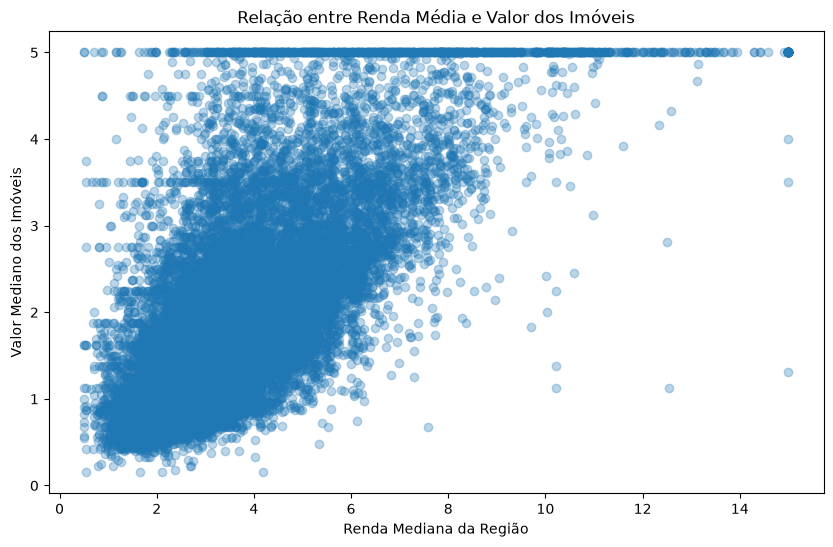

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.title("Relação entre Renda Média e Valor dos Imóveis")
plt.xlabel("Renda Mediana da Região")
plt.ylabel("Valor Mediano dos Imóveis")

plt.show()

Ah sim, quanto mais subimos para regioes mais ricas, o valor dos imoveis sobe

Regiões com maior renda mediana tendem a apresentar imóveis com maior valor mediano.

### 4.4 Correlação entre as Variáveis
Até agora estamos olhando para gráficos. Agora quero te apresentar uma ferramenta muito importante em análise de dados: correlação (df.corr()).
Ela nos ajuda a quantificar o quanto duas variáveis estão relacionadas.

A correlação geralmente fica entre:
-1  ←──────── 0 ────────→  +1

De maneira simplificada:
- próximo de +1: relação positiva;
- próximo de -1: relação negativa;
- próximo de 0: pouca relação linear.

renda ↑  → preço ↑
correlação positiva
X ↑ → Y ↓
correlação negativa
-> correlação mede associação, não prova causa.

A variável com a correlação mais forte com MedHouseVal é:
MedInc: 0.688
Regiões com maior renda mediana tendem a apresentar valores medianos de imóveis mais elevados.

In [6]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


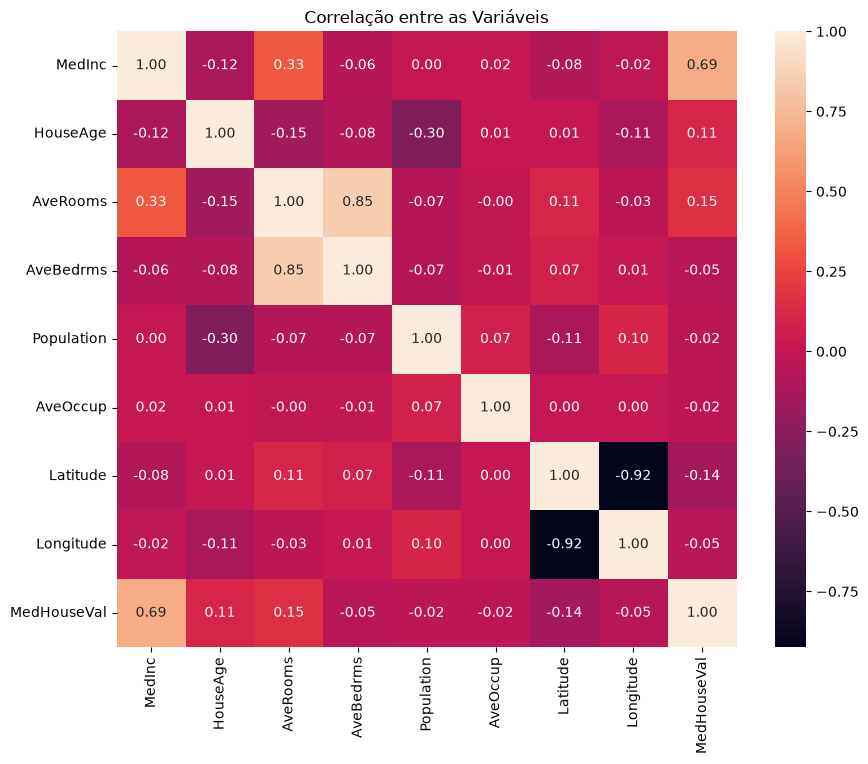

In [7]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlação entre as Variáveis")

plt.show()

A renda mediana (MedInc) apresenta, de longe, a relação linear mais forte com o valor mediano dos imóveis (MedHouseVal).

Porém, análise individual de variáveis nem sempre mostra todo o padrão existente nos dados.

### 4.5 Localização Geográfica e Valor dos Imóveis

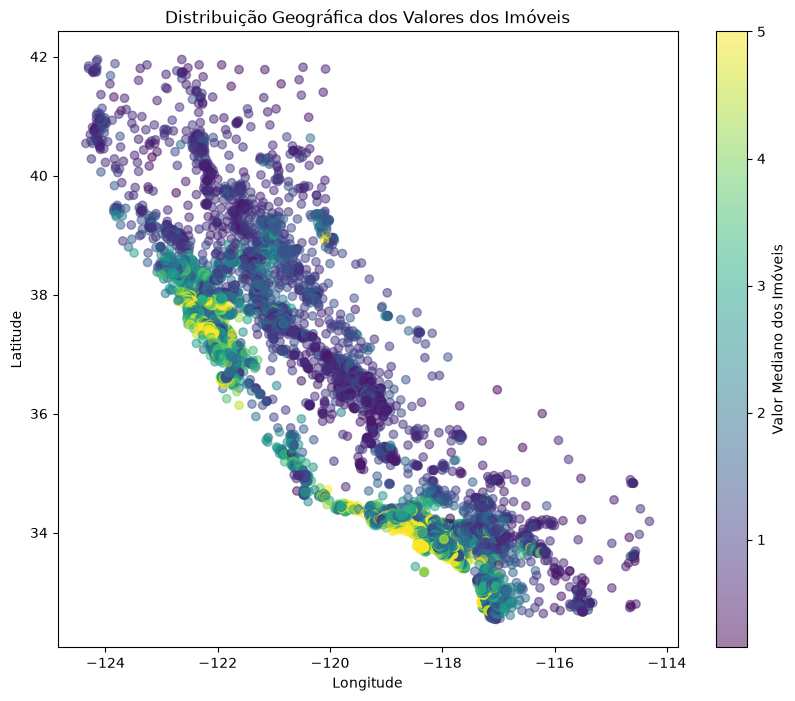

In [8]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    alpha=0.5
)

plt.colorbar(label="Valor Mediano dos Imóveis")
plt.title("Distribuição Geográfica dos Valores dos Imóveis")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

🗺️ Sobre o formato do gráfico
Sim, ele lembra o formato da Califórnia porque os dados possuem coordenadas reais de regiões do estado:
- Longitude → posição horizontal;
- Latitude → posição vertical.
Então, ao combinar as duas variáveis, acabamos criando uma representação geográfica simplificada da distribuição dos registros.

Observou-se que regiões próximas à costa aparentam possuir uma concentração maior de imóveis com valores elevados.

O gráfico indica que os valores não estão distribuídos aleatoriamente pelo território. Existem áreas específicas com maior concentração de valores elevados.

Isso também ajuda a entender algo que vimos anteriormente:
As variáveis de Latitude e Longitude, analisadas individualmente, apresentavam correlações relativamente fracas com MedHouseVal, mas quando combinamos as duas variáveis como localização, aparece um padrão muito mais claro.

### Insight sobre localização

A distribuição dos valores dos imóveis apresenta um padrão geográfico e não ocorre de forma aleatória.

Regiões próximas à costa aparentam concentrar uma quantidade maior de imóveis com valores elevados, enquanto outras regiões apresentam predominantemente valores mais baixos.

Essa análise também mostra que latitude e longitude, quando analisadas conjuntamente, podem fornecer informações mais relevantes do que quando avaliadas isoladamente.

Mas a partir de tudo isso, como conseguimos utilizar essas características para estimar o valor dos imóveis?

Antes de treinar qualquer modelo de ML para responder isso, vamos entender uma estrutura fundamental:

(Variáveis)
Características → Modelo → Previsão
       X             ↓        ŷ

Valor real → Comparação
     y

Valor que queremos prever (y): MedHouseVal

Agora, devemos começar a responder:
É possível estimar o valor dos imóveis utilizando as características disponíveis?

Para isso, vamos separar o DataFrame.

(y) target: MedHouseVal
(x) nformações usadas para fazer a previsão (tudo menos o y)

## 6. Preparação para Machine Learning:

In [10]:
x = df.drop(columns="MedHouseVal")

y = df["MedHouseVal"]

print("Dimensão de X:", x.shape)
print("Dimensão de y:", y.shape)

x.head()

Dimensão de X: (20640, 8)
Dimensão de y: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df["MedHouseVal"].describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

In [ ]:
df["MedHouseVal"].value_counts()

MedHouseVal
5.00001    965
1.37500    122
1.62500    117
1.12500    103
1.87500     93
          ... 
4.22900      1
3.49400      1
4.25800      1
2.00700      1
0.47000      1
Name: count, Length: 3842, dtype: int64

In [ ]:
linhas, colunas = df.shape

print(f"Quantidade de linhas: {linhas}")
print(f"Quantidade de colunas: {colunas}")

Quantidade de linhas: 20640
Quantidade de colunas: 9


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
print(dados.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g